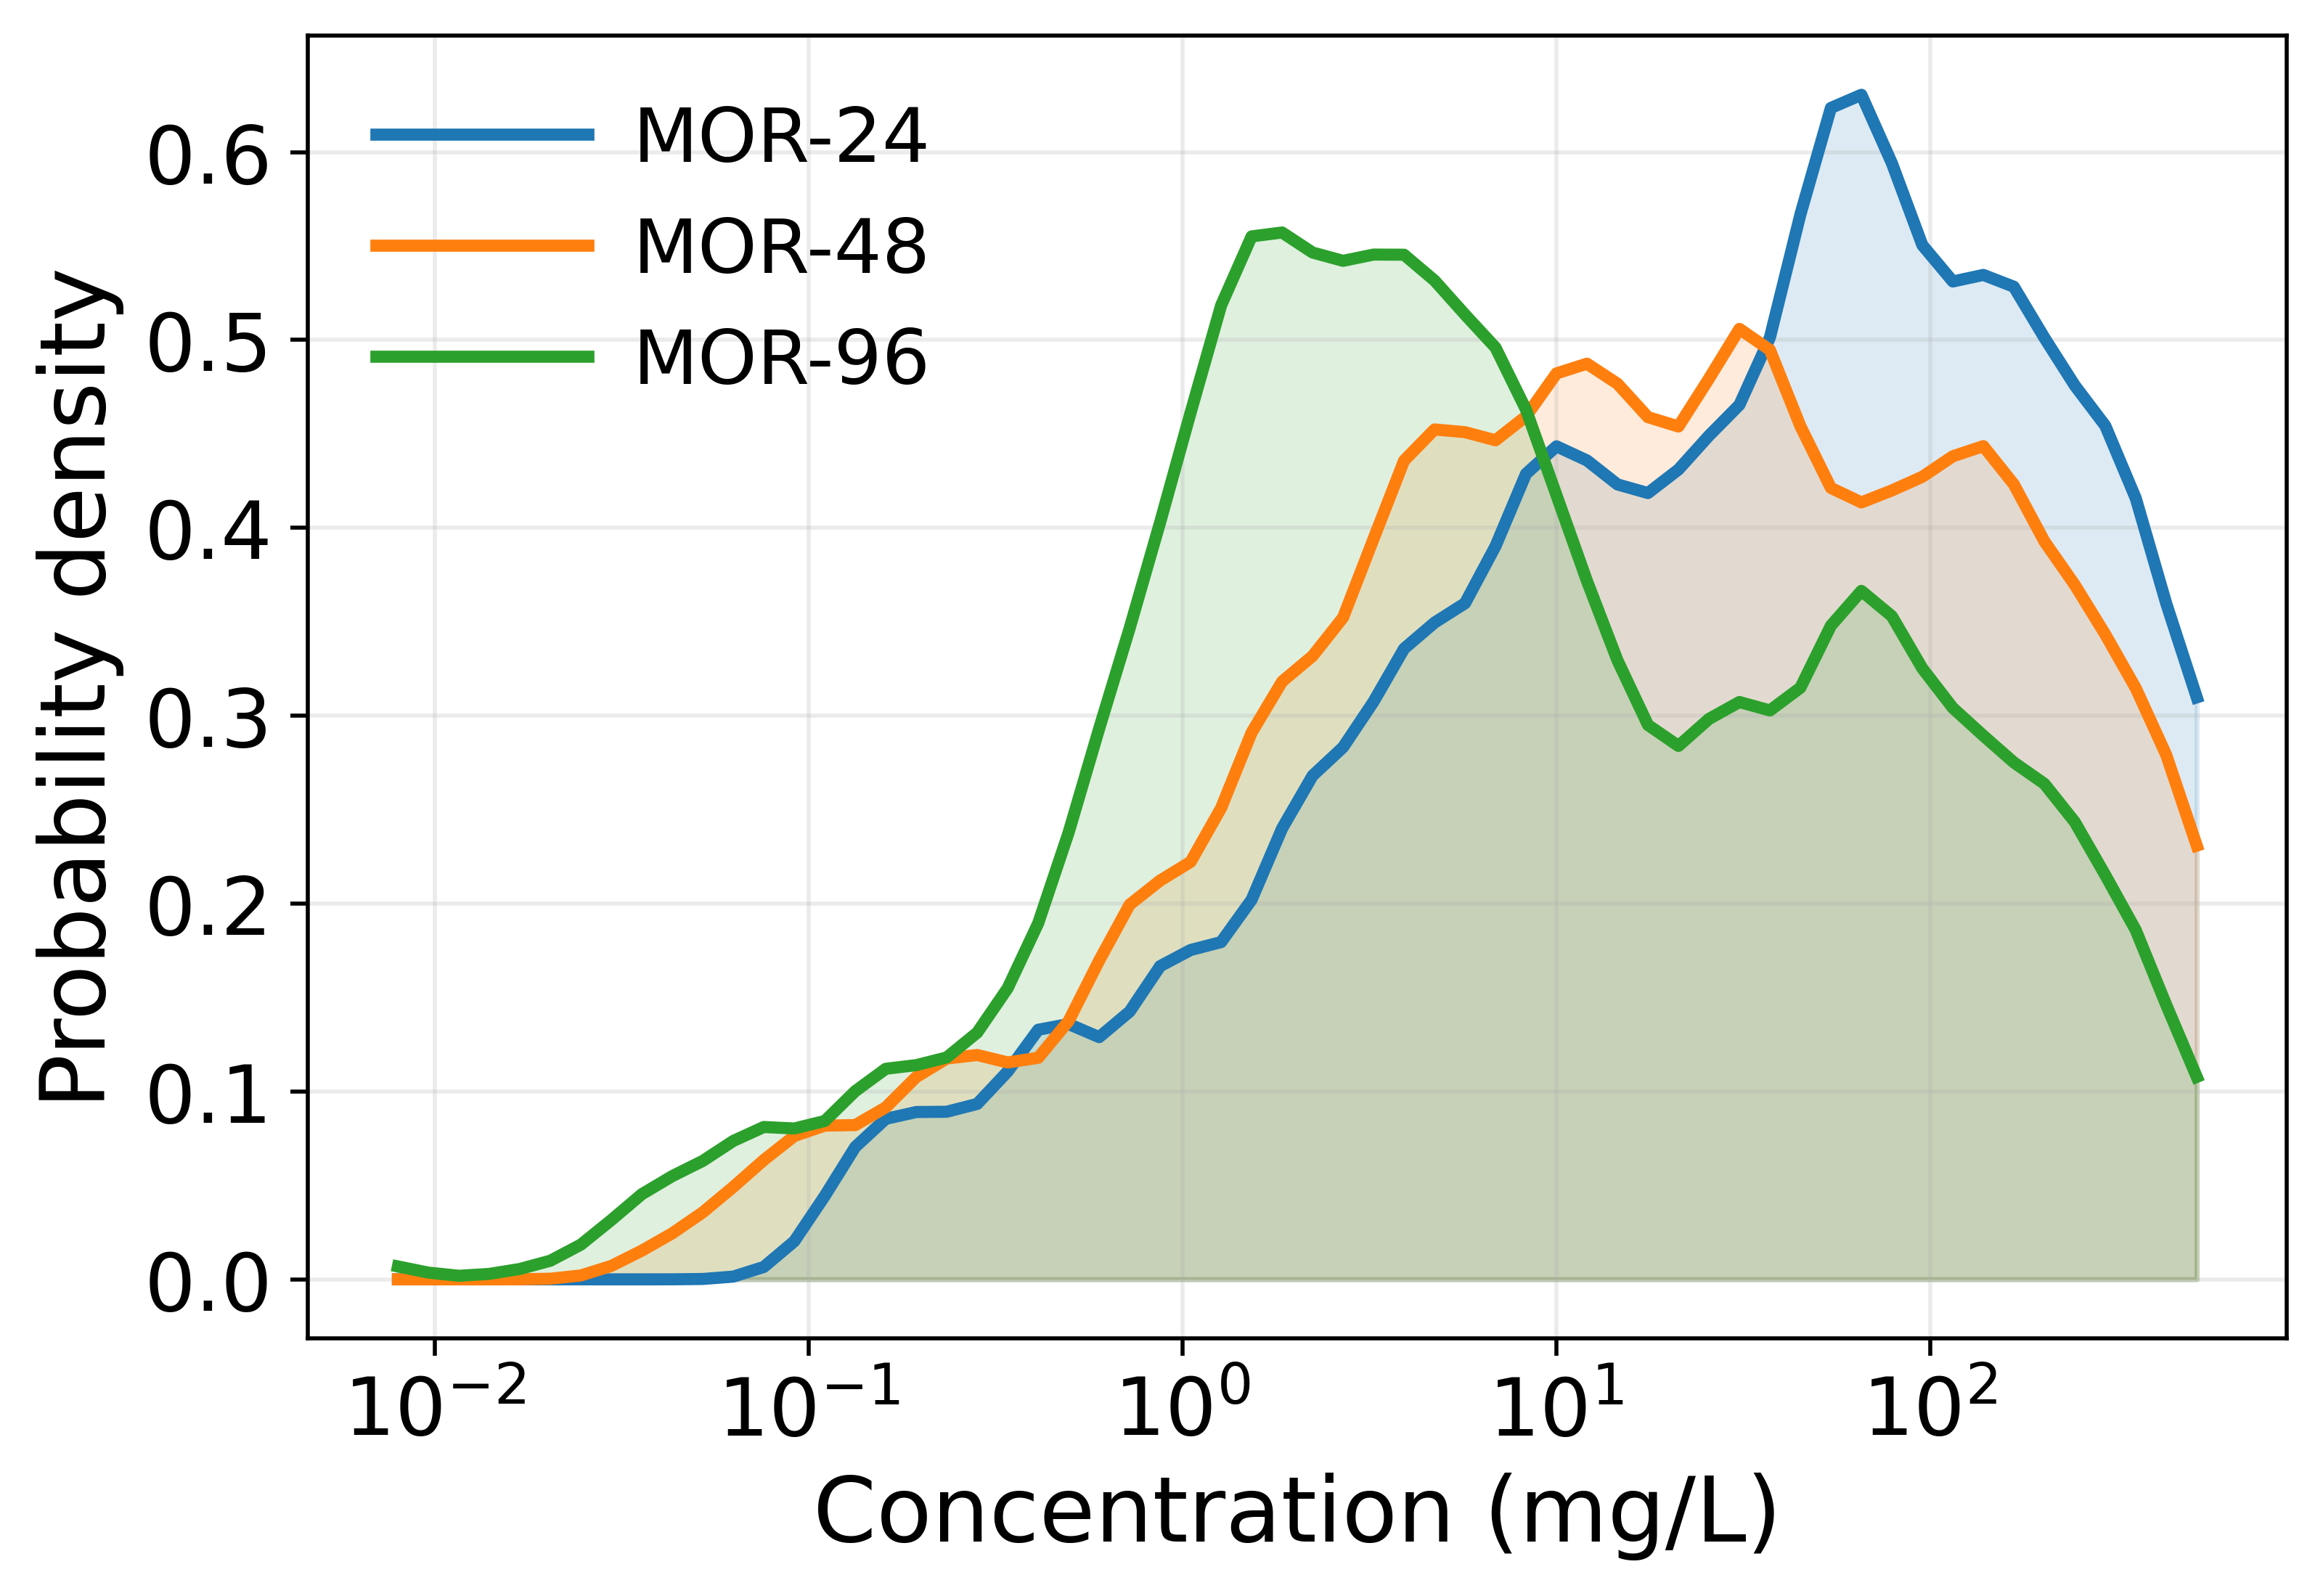

In [2]:
files = {
    ("MOR",  24): "./invertebrates_LC50_MOR_24.xlsx",
    ("MOR",  48): "./invertebrates_LC50_MOR_48.xlsx",
    ("MOR",  96): "./invertebrates_LC50_MOR_96.xlsx",
}
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
from scipy.ndimage import gaussian_filter1d

# === 读取数据（与你现有的一样）===

CANDS = ["mgperL","pred_mgperL","concentration","Concentration","conc","Conc","toxicity","Toxicity","EC10","value","Value"]
def pick_col(df):
    for c in CANDS:
        if c in df.columns: return c, "linear"
    num = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    return (num[0], "linear") if num else (_ for _ in ()).throw(ValueError("no numeric col"))
def load_vals(p):
    df = pd.read_excel(p)
    col, mode = pick_col(df)
    x = pd.to_numeric(df[col], errors="coerce").dropna().values
    return x[(x>=0) & np.isfinite(x)]
series = {k: load_vals(p) for k,p in files.items()}

# === 公共对数分箱 ===
all_vals = np.concatenate([v for v in series.values() if len(v)>0])
xmin = max(all_vals.min(), 1e-8)
xmax = np.percentile(all_vals, 99)
BINS = 60
bins = np.logspace(np.log10(xmin), np.log10(xmax), BINS+1)
bins_log = np.log10(bins)
centers_log = 0.5*(bins_log[:-1] + bins_log[1:])
widths_log = np.diff(bins_log)

colors = {0:"#1f77b4",1:"#ff7f0e",2:"#2ca02c"}  # 时间rank配色
times = sorted(set(t for (_,t) in series.keys()))
rank = {t:i for i,t in enumerate(times)}

# ===== 字体大小 =====
LABEL_FS  = 18
TICK_FS   = 16
LEGEND_FS = 15
TITLE_FS  = 20  # 若你要加标题可用

plt.figure(figsize=(6.5,4.5), dpi=500)
areas = {}

for (eff,t), x in series.items():
    counts, _ = np.histogram(x, bins=bins)
    N = counts.sum() if counts.sum()>0 else 1.0

    # 每 log10 单位的密度 + 平滑
    density = counts.astype(float) / (N * widths_log)
    density = gaussian_filter1d(density, sigma=1.2, mode="nearest")

    # 在 log 空间归一化：∫ density d(log10 x) = 1
    area = np.trapz(density, x=centers_log)
    if area > 0:
        density /= area
    areas[(eff,t)] = np.trapz(density, x=centers_log)

    c = colors[rank[t]]
    plt.fill_between(centers_log, 0, density, color=c, alpha=0.15, label="_nolegend_")
    plt.plot(centers_log, density, color=c, lw=2.4, label=f"{eff}-{t}")

# 线性轴 + 指数刻度格式
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(6))
ax.xaxis.set_major_formatter(FuncFormatter(lambda v,_: r"$10^{%d}$" % int(np.round(v))))

# 字体与刻度
ax.set_xlabel("Concentration (mg/L)", fontsize=LABEL_FS)
ax.set_ylabel("Probability density", fontsize=LABEL_FS)
# ax.set_title("Invertebrates EC10 (REP)", fontsize=TITLE_FS)

ax.tick_params(axis="both", which="major", labelsize=TICK_FS)
ax.tick_params(axis="both", which="minor", labelsize=TICK_FS-2)

plt.grid(alpha=0.25)
plt.legend(frameon=False, ncol=1, loc="upper left",
           fontsize=LEGEND_FS, handlelength=2.8, handletextpad=0.6)
plt.tight_layout()
plt.show()